In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [2]:
# from google.colab import drive
# drive.mount('/content/drive')

In [3]:
# train 데이터
data = pd.read_csv('/Users/yub/Documents/ssu_32/CapstoneDesign1/Datasets/NF-UNSW-NB15-v3.csv')
data.head()

,FLOW_START_MILLISECONDS,FLOW_END_MILLISECONDS,IPV4_SRC_ADDR,L4_SRC_PORT,IPV4_DST_ADDR,L4_DST_PORT,PROTOCOL,L7_PROTO,IN_BYTES,IN_PKTS,...,SRC_TO_DST_IAT_MIN,SRC_TO_DST_IAT_MAX,SRC_TO_DST_IAT_AVG,SRC_TO_DST_IAT_STDDEV,DST_TO_SRC_IAT_MIN,DST_TO_SRC_IAT_MAX,DST_TO_SRC_IAT_AVG,DST_TO_SRC_IAT_STDDEV,Label,Attack
0,1424242193040,1424242193043,59.166.0.2,4894,149.171.126.3,53,17,5.0,146,2,...,0,0,0,0,0,0,0,0,0,Benign
1,1424242192744,1424242193079,59.166.0.4,52671,149.171.126.6,31992,6,11.0,4704,28,...,0,91,12,19,0,90,12,19,0,Benign
2,1424242190649,1424242193109,59.166.0.0,47290,149.171.126.9,6881,6,37.0,13662,238,...,0,1843,10,119,0,1843,5,88,0,Benign
3,1424242193145,1424242193146,59.166.0.8,43310,149.171.126.7,53,17,5.0,146,2,...,0,0,0,0,0,0,0,0,0,Benign
4,1424242193239,1424242193241,59.166.0.1,45870,149.171.126.1,53,17,5.0,130,2,...,0,0,0,0,0,0,0,0,0,Benign


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2365424 entries, 0 to 2365423
Data columns (total 55 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   FLOW_START_MILLISECONDS      int64  
 1   FLOW_END_MILLISECONDS        int64  
 2   IPV4_SRC_ADDR                object 
 3   L4_SRC_PORT                  int64  
 4   IPV4_DST_ADDR                object 
 5   L4_DST_PORT                  int64  
 6   PROTOCOL                     int64  
 7   L7_PROTO                     float64
 8   IN_BYTES                     int64  
 9   IN_PKTS                      int64  
 10  OUT_BYTES                    int64  
 11  OUT_PKTS                     int64  
 12  TCP_FLAGS                    int64  
 13  CLIENT_TCP_FLAGS             int64  
 14  SERVER_TCP_FLAGS             int64  
 15  FLOW_DURATION_MILLISECONDS   int64  
 16  DURATION_IN                  int64  
 17  DURATION_OUT                 int64  
 18  MIN_TTL                      int64  
 19  

In [5]:
#결측치 확인
#SRC_TO_DST_SECOND_BYTES == TRUE(결측치 존재)
data.isnull().any()

FLOW_START_MILLISECONDS        False
FLOW_END_MILLISECONDS          False
IPV4_SRC_ADDR                  False
L4_SRC_PORT                    False
IPV4_DST_ADDR                  False
L4_DST_PORT                    False
PROTOCOL                       False
L7_PROTO                       False
IN_BYTES                       False
IN_PKTS                        False
OUT_BYTES                      False
OUT_PKTS                       False
TCP_FLAGS                      False
CLIENT_TCP_FLAGS               False
SERVER_TCP_FLAGS               False
FLOW_DURATION_MILLISECONDS     False
DURATION_IN                    False
DURATION_OUT                   False
MIN_TTL                        False
MAX_TTL                        False
LONGEST_FLOW_PKT               False
SHORTEST_FLOW_PKT              False
MIN_IP_PKT_LEN                 False
MAX_IP_PKT_LEN                 False
SRC_TO_DST_SECOND_BYTES         True
DST_TO_SRC_SECOND_BYTES        False
RETRANSMITTED_IN_BYTES         False
R

In [6]:
data.isna().mean()

FLOW_START_MILLISECONDS        0.000000
FLOW_END_MILLISECONDS          0.000000
IPV4_SRC_ADDR                  0.000000
L4_SRC_PORT                    0.000000
IPV4_DST_ADDR                  0.000000
L4_DST_PORT                    0.000000
PROTOCOL                       0.000000
L7_PROTO                       0.000000
IN_BYTES                       0.000000
IN_PKTS                        0.000000
OUT_BYTES                      0.000000
OUT_PKTS                       0.000000
TCP_FLAGS                      0.000000
CLIENT_TCP_FLAGS               0.000000
SERVER_TCP_FLAGS               0.000000
FLOW_DURATION_MILLISECONDS     0.000000
DURATION_IN                    0.000000
DURATION_OUT                   0.000000
MIN_TTL                        0.000000
MAX_TTL                        0.000000
LONGEST_FLOW_PKT               0.000000
SHORTEST_FLOW_PKT              0.000000
MIN_IP_PKT_LEN                 0.000000
MAX_IP_PKT_LEN                 0.000000
SRC_TO_DST_SECOND_BYTES        0.026813


In [7]:
#전체 feature(columns) 변수로 지정
col=list(data.columns)

#1. Feature 0~9 전처리

In [8]:
#feature 0~9번째
data[col[:10]].head()

,FLOW_START_MILLISECONDS,FLOW_END_MILLISECONDS,IPV4_SRC_ADDR,L4_SRC_PORT,IPV4_DST_ADDR,L4_DST_PORT,PROTOCOL,L7_PROTO,IN_BYTES,IN_PKTS
0,1424242193040,1424242193043,59.166.0.2,4894,149.171.126.3,53,17,5.0,146,2
1,1424242192744,1424242193079,59.166.0.4,52671,149.171.126.6,31992,6,11.0,4704,28
2,1424242190649,1424242193109,59.166.0.0,47290,149.171.126.9,6881,6,37.0,13662,238
3,1424242193145,1424242193146,59.166.0.8,43310,149.171.126.7,53,17,5.0,146,2
4,1424242193239,1424242193241,59.166.0.1,45870,149.171.126.1,53,17,5.0,130,2


In [9]:
#IPV4_SRC_ADDR, IPV4_DST_ADDR는 drop(맨 마지막에 수행)

In [10]:
#L7_PROTO: 이상 데이터 존재(7.253, 7.212, 7.291, 7.126, 7.18, 10.41)
#  ==> 마지막에 drop
print(col[7])
data[col[7]].unique()

L7_PROTO


array([  5.   ,  11.   ,  37.   ,   0.   ,   4.   ,  41.   ,  36.   ,
        92.   ,   3.   ,  13.   ,   7.   ,   1.   ,  85.   ,  10.16 ,
        14.   , 370.   ,  12.   , 112.   ,  97.   ,   2.   ,   7.37 ,
        96.   ,  20.   ,   7.253, 152.   , 100.   ,   7.212,  81.   ,
       114.   ,  50.   ,  91.   , 131.   ,  95.   ,  79.   , 115.   ,
        10.   ,  84.   ,   7.376, 175.   ,  30.   , 111.   , 154.   ,
        44.   ,  18.   ,  88.   , 164.   , 222.   ,  32.   ,  89.   ,
        17.   ,  65.   , 172.   ,  10.41 ,  77.   , 139.   ,   7.5  ,
        51.   , 216.   ,  82.   ,  87.   , 410.   , 227.   , 378.   ,
       353.   , 168.   , 146.   ,  80.   ,   9.   , 259.   ,  19.   ,
       332.   , 144.   , 237.   , 167.   , 416.   ,  93.   , 161.   ,
       214.   ,   7.291, 345.   , 223.   ,  60.   , 253.   ,   8.   ,
       397.   , 128.   , 367.   , 365.   , 297.   ,  73.   , 296.   ,
       174.   , 159.   , 343.   ,  83.   , 391.   , 213.   , 244.   ,
        53.   , 383.

In [11]:
#feature: IN_BYTES
print(data['IN_BYTES'].min())
print(data['IN_BYTES'].max())

1
27020934


(array([8.70000e+01, 4.54310e+04, 2.20000e+01, 2.99000e+02, 2.34460e+04,
        4.22448e+05, 3.05555e+05, 2.24598e+05, 7.68492e+05, 3.16812e+05,
        1.33444e+05, 1.15882e+05, 6.42800e+03, 1.28400e+03, 6.15000e+02,
        3.70000e+02, 8.60000e+01, 3.70000e+01, 7.40000e+01, 1.40000e+01]),
 array([ 0.69314718,  1.51409595,  2.33504471,  3.15599348,  3.97694224,
         4.79789101,  5.61883977,  6.43978854,  7.26073731,  8.08168607,
         8.90263484,  9.7235836 , 10.54453237, 11.36548113, 12.1864299 ,
        13.00737867, 13.82832743, 14.6492762 , 15.47022496, 16.29117373,
        17.11212249]),
 <BarContainer object of 20 artists>)

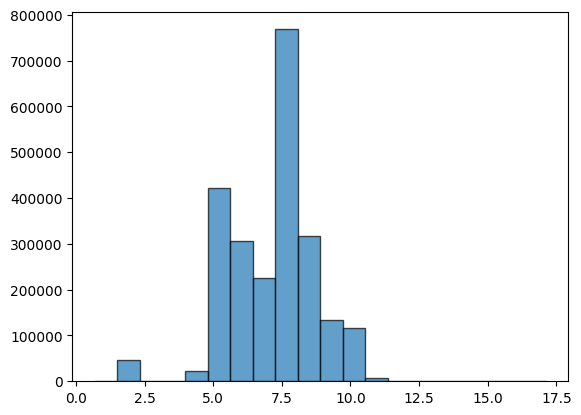

In [12]:
#feature: IN_BYTES(분포 커서 log -> standardscaler)
data['IN_BYTES'] = np.log1p(data['IN_BYTES'])
plt.hist(data['IN_BYTES'], bins=20, edgecolor='k', alpha=0.7)

In [13]:
data['IN_BYTES']  = scaler.fit_transform(data[['IN_BYTES']])

In [14]:
data[col[:10]].head()

,FLOW_START_MILLISECONDS,FLOW_END_MILLISECONDS,IPV4_SRC_ADDR,L4_SRC_PORT,IPV4_DST_ADDR,L4_DST_PORT,PROTOCOL,L7_PROTO,IN_BYTES,IN_PKTS
0,1424242193040,1424242193043,59.166.0.2,4894,149.171.126.3,53,17,5.0,-1.322581,2
1,1424242192744,1424242193079,59.166.0.4,52671,149.171.126.6,31992,6,11.0,0.845318,28
2,1424242190649,1424242193109,59.166.0.0,47290,149.171.126.9,6881,6,37.0,1.512126,238
3,1424242193145,1424242193146,59.166.0.8,43310,149.171.126.7,53,17,5.0,-1.322581,2
4,1424242193239,1424242193241,59.166.0.1,45870,149.171.126.1,53,17,5.0,-1.394659,2


#Feature 10~19 전처리

In [15]:
#feature 10~19번째
data[col[10:20]].head()

,OUT_BYTES,OUT_PKTS,TCP_FLAGS,CLIENT_TCP_FLAGS,SERVER_TCP_FLAGS,FLOW_DURATION_MILLISECONDS,DURATION_IN,DURATION_OUT,MIN_TTL,MAX_TTL
0,178,2,0,0,0,2,0,0,31,31
1,2976,28,27,27,27,335,334,334,31,32
2,548216,438,27,27,27,2460,2459,2459,31,32
3,178,2,0,0,0,1,0,0,31,31
4,162,2,0,0,0,1,0,0,31,31


In [16]:
#feature: OUT_BYTES
print(data['OUT_BYTES'].min())
print(data['OUT_BYTES'].max())

0
14656752


(array([6.61210e+04, 0.00000e+00, 5.00000e+01, 0.00000e+00, 7.10000e+01,
        9.03300e+03, 5.96332e+05, 7.94840e+04, 2.26629e+05, 5.42512e+05,
        4.65390e+04, 3.14749e+05, 2.58480e+05, 1.52891e+05, 5.28700e+03,
        8.63200e+03, 5.55840e+04, 2.96700e+03, 4.00000e+01, 2.30000e+01]),
 array([ 0.        ,  0.82502059,  1.65004117,  2.47506176,  3.30008235,
         4.12510294,  4.95012352,  5.77514411,  6.6001647 ,  7.42518528,
         8.25020587,  9.07522646,  9.90024705, 10.72526763, 11.55028822,
        12.37530881, 13.20032939, 14.02534998, 14.85037057, 15.67539116,
        16.50041174]),
 <BarContainer object of 20 artists>)

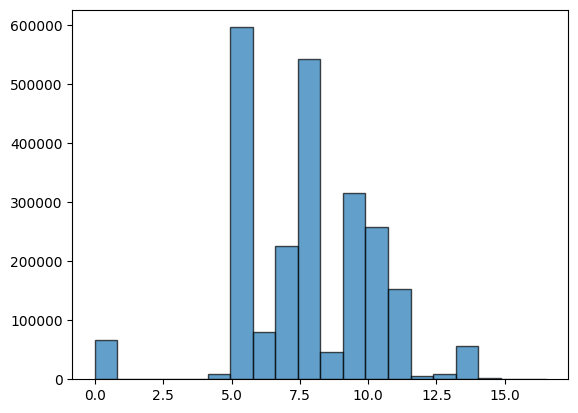

In [17]:
#feature: OUT_BYTES(분포 커서 log -> standardscaler)
data['OUT_BYTES'] = np.log1p(data['OUT_BYTES'])
plt.hist(data['OUT_BYTES'], bins=20, edgecolor='k', alpha=0.7)

In [18]:
data['OUT_BYTES']  = scaler.fit_transform(data[['OUT_BYTES']])

In [19]:
#변경 내용 확인
data[col[10:20]].head()

,OUT_BYTES,OUT_PKTS,TCP_FLAGS,CLIENT_TCP_FLAGS,SERVER_TCP_FLAGS,FLOW_DURATION_MILLISECONDS,DURATION_IN,DURATION_OUT,MIN_TTL,MAX_TTL
0,-1.023279,2,0,0,0,2,0,0,31,31
1,0.111115,28,27,27,27,335,334,334,31,32
2,2.215747,438,27,27,27,2460,2459,2459,31,32
3,-1.023279,2,0,0,0,1,0,0,31,31
4,-1.061062,2,0,0,0,1,0,0,31,31


#Feature 20~29 전처리

In [20]:
#feature 20~29번째
data[col[20:30]].head(10)

,LONGEST_FLOW_PKT,SHORTEST_FLOW_PKT,MIN_IP_PKT_LEN,MAX_IP_PKT_LEN,SRC_TO_DST_SECOND_BYTES,DST_TO_SRC_SECOND_BYTES,RETRANSMITTED_IN_BYTES,RETRANSMITTED_IN_PKTS,RETRANSMITTED_OUT_BYTES,RETRANSMITTED_OUT_PKTS
0,89,73,73,89,89.000000,73.000000,0,0,0,0
1,984,52,52,984,8.883582,14.041791,1988,7,1068,6
2,1500,52,52,1500,222.852033,5.553659,1735,21,272908,196
3,89,73,73,89,178.000000,146.000000,0,0,0,0
4,81,65,65,81,162.000000,130.000000,0,0,0,0
5,811,52,52,811,647.333333,106.666667,56,1,811,1
6,1500,52,52,1500,1470.666667,70.666667,56,1,4252,3
7,1500,52,52,1500,40.000000,1116.000000,4308,4,0,0
8,106,52,52,106,116.666667,82.900000,563,9,1126,13
9,40,40,40,40,0.106101,0.212202,40,1,0,0


In [21]:
#SHORTEST_FLOW_PKT와 MIN_IP_PKT_LEN feature가 항상 동일한지 확인 => 거짓.
(data['SHORTEST_FLOW_PKT'] == data['MIN_IP_PKT_LEN']).all()

np.False_

In [22]:
#SHORTEST_FLOW_PKT와 MIN_IP_PKT_LEN 다른 행 확인
diff_rows = data[data['SHORTEST_FLOW_PKT'] != data['MIN_IP_PKT_LEN']]
diff_rows[col[20:30]]

,LONGEST_FLOW_PKT,SHORTEST_FLOW_PKT,MIN_IP_PKT_LEN,MAX_IP_PKT_LEN,SRC_TO_DST_SECOND_BYTES,DST_TO_SRC_SECOND_BYTES,RETRANSMITTED_IN_BYTES,RETRANSMITTED_IN_PKTS,RETRANSMITTED_OUT_BYTES,RETRANSMITTED_OUT_PKTS
40,532,532,0,532,NaN,inf,0,0,0,0
71,52,52,0,52,NaN,inf,0,0,0,0
101,532,532,0,532,NaN,inf,0,0,0,0
139,52,52,0,52,NaN,inf,0,0,0,0
166,532,532,0,532,NaN,inf,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...
2356245,64,64,0,64,0.0,0.006933,0,0,0,0
2359891,64,64,0,64,0.0,0.006933,0,0,0,0
2359892,64,64,0,64,0.0,0.006933,0,0,0,0
2363191,64,64,0,64,0.0,0.007199,0,0,0,0


In [23]:
#LONGEST_FLOW_PKT와 MAX_IP_PKT_LEN는 항상 일치 => 한 feature는 제거 가능
diff_rows = data[data['LONGEST_FLOW_PKT'] != data['MAX_IP_PKT_LEN']]
diff_rows[col[20:30]]

,LONGEST_FLOW_PKT,SHORTEST_FLOW_PKT,MIN_IP_PKT_LEN,MAX_IP_PKT_LEN,SRC_TO_DST_SECOND_BYTES,DST_TO_SRC_SECOND_BYTES,RETRANSMITTED_IN_BYTES,RETRANSMITTED_IN_PKTS,RETRANSMITTED_OUT_BYTES,RETRANSMITTED_OUT_PKTS


In [24]:
#SRC_TO_DST_SECOND_BYTES(전송률) 결측치(NaN) 확인
import pandas as pd
pd.set_option('display.max_columns', None)

df=data[data['SRC_TO_DST_SECOND_BYTES'].isnull()]
df

,FLOW_START_MILLISECONDS,FLOW_END_MILLISECONDS,IPV4_SRC_ADDR,L4_SRC_PORT,IPV4_DST_ADDR,L4_DST_PORT,PROTOCOL,L7_PROTO,IN_BYTES,IN_PKTS,OUT_BYTES,OUT_PKTS,TCP_FLAGS,CLIENT_TCP_FLAGS,SERVER_TCP_FLAGS,FLOW_DURATION_MILLISECONDS,DURATION_IN,DURATION_OUT,MIN_TTL,MAX_TTL,LONGEST_FLOW_PKT,SHORTEST_FLOW_PKT,MIN_IP_PKT_LEN,MAX_IP_PKT_LEN,SRC_TO_DST_SECOND_BYTES,DST_TO_SRC_SECOND_BYTES,RETRANSMITTED_IN_BYTES,RETRANSMITTED_IN_PKTS,RETRANSMITTED_OUT_BYTES,RETRANSMITTED_OUT_PKTS,SRC_TO_DST_AVG_THROUGHPUT,DST_TO_SRC_AVG_THROUGHPUT,NUM_PKTS_UP_TO_128_BYTES,NUM_PKTS_128_TO_256_BYTES,NUM_PKTS_256_TO_512_BYTES,NUM_PKTS_512_TO_1024_BYTES,NUM_PKTS_1024_TO_1514_BYTES,TCP_WIN_MAX_IN,TCP_WIN_MAX_OUT,ICMP_TYPE,ICMP_IPV4_TYPE,DNS_QUERY_ID,DNS_QUERY_TYPE,DNS_TTL_ANSWER,FTP_COMMAND_RET_CODE,SRC_TO_DST_IAT_MIN,SRC_TO_DST_IAT_MAX,SRC_TO_DST_IAT_AVG,SRC_TO_DST_IAT_STDDEV,DST_TO_SRC_IAT_MIN,DST_TO_SRC_IAT_MAX,DST_TO_SRC_IAT_AVG,DST_TO_SRC_IAT_STDDEV,Label,Attack
40,1424242194737,1424242194737,175.45.176.2,5075,149.171.126.16,520,17,0.0,-0.083935,2,-3.116464,0,0,0,0,0,0,0,254,254,532,532,0,532,NaN,inf,0,0,0,0,8512000,0,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,Fuzzers
71,1424242195905,1424242195905,175.45.176.2,36547,149.171.126.16,520,17,0.0,-1.533040,2,-3.116464,0,0,0,0,0,0,0,254,254,52,52,0,52,NaN,inf,0,0,0,0,832000,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,Fuzzers
101,1424242197085,1424242197085,175.45.176.2,3907,149.171.126.16,520,17,0.0,-0.083935,2,-3.116464,0,0,0,0,0,0,0,254,254,532,532,0,532,NaN,inf,0,0,0,0,8512000,0,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,Fuzzers
139,1424242198664,1424242198664,175.45.176.2,60481,149.171.126.16,520,17,0.0,-1.533040,2,-3.116464,0,0,0,0,0,0,0,254,254,52,52,0,52,NaN,inf,0,0,0,0,832000,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,Fuzzers
166,1424242199820,1424242199820,175.45.176.2,61464,149.171.126.16,520,17,0.0,-0.083935,2,-3.116464,0,0,0,0,0,0,0,254,254,532,532,0,532,NaN,inf,0,0,0,0,8512000,0,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,Fuzzers
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2347576,1421972017149,1421972017149,149.171.126.3,111,59.166.0.1,54781,17,37.0,-1.695360,1,-3.116464,0,0,0,0,0,0,0,0,0,80,80,0,80,NaN,inf,0,0,0,0,640000,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,Benign
2347791,1421972022952,1421972022952,59.166.0.2,47197,149.171.126.5,32716,6,37.0,-1.915154,1,-3.116464,0,2,2,0,0,0,0,0,0,56,56,0,56,NaN,inf,0,0,0,0,448000,0,1,0,0,0,0,5792,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,Benign
2347863,1421972024948,1421972024948,149.171.126.7,111,59.166.0.0,2806,17,37.0,-1.727037,1,-3.116464,0,0,0,0,0,0,0,0,0,76,76,0,76,NaN,inf,0,0,0,0,608000,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,Benign
2348939,1421972057048,1421972057048,149.171.126.0,53,59.166.0.5,1540,17,5.0,-1.629459,1,-3.116464,0,0,0,0,0,0,0,0,0,89,89,0,89,NaN,inf,0,0,0,0,712000,0,1,0,0,0,0,0,0,0,0,41889,1,60,0,0,0,0,0,0,0,0,0,0,Benign


In [25]:
#SRC_TO_DST_SECOND_BYTES: 결측치+공격 데이터 확인
data[(data[col[24]].isnull()) & (data['Attack']!='Benign')  ]

,FLOW_START_MILLISECONDS,FLOW_END_MILLISECONDS,IPV4_SRC_ADDR,L4_SRC_PORT,IPV4_DST_ADDR,L4_DST_PORT,PROTOCOL,L7_PROTO,IN_BYTES,IN_PKTS,OUT_BYTES,OUT_PKTS,TCP_FLAGS,CLIENT_TCP_FLAGS,SERVER_TCP_FLAGS,FLOW_DURATION_MILLISECONDS,DURATION_IN,DURATION_OUT,MIN_TTL,MAX_TTL,LONGEST_FLOW_PKT,SHORTEST_FLOW_PKT,MIN_IP_PKT_LEN,MAX_IP_PKT_LEN,SRC_TO_DST_SECOND_BYTES,DST_TO_SRC_SECOND_BYTES,RETRANSMITTED_IN_BYTES,RETRANSMITTED_IN_PKTS,RETRANSMITTED_OUT_BYTES,RETRANSMITTED_OUT_PKTS,SRC_TO_DST_AVG_THROUGHPUT,DST_TO_SRC_AVG_THROUGHPUT,NUM_PKTS_UP_TO_128_BYTES,NUM_PKTS_128_TO_256_BYTES,NUM_PKTS_256_TO_512_BYTES,NUM_PKTS_512_TO_1024_BYTES,NUM_PKTS_1024_TO_1514_BYTES,TCP_WIN_MAX_IN,TCP_WIN_MAX_OUT,ICMP_TYPE,ICMP_IPV4_TYPE,DNS_QUERY_ID,DNS_QUERY_TYPE,DNS_TTL_ANSWER,FTP_COMMAND_RET_CODE,SRC_TO_DST_IAT_MIN,SRC_TO_DST_IAT_MAX,SRC_TO_DST_IAT_AVG,SRC_TO_DST_IAT_STDDEV,DST_TO_SRC_IAT_MIN,DST_TO_SRC_IAT_MAX,DST_TO_SRC_IAT_AVG,DST_TO_SRC_IAT_STDDEV,Label,Attack
40,1424242194737,1424242194737,175.45.176.2,5075,149.171.126.16,520,17,0.0,-0.083935,2,-3.116464,0,0,0,0,0,0,0,254,254,532,532,0,532,NaN,inf,0,0,0,0,8512000,0,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,Fuzzers
71,1424242195905,1424242195905,175.45.176.2,36547,149.171.126.16,520,17,0.0,-1.533040,2,-3.116464,0,0,0,0,0,0,0,254,254,52,52,0,52,NaN,inf,0,0,0,0,832000,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,Fuzzers
101,1424242197085,1424242197085,175.45.176.2,3907,149.171.126.16,520,17,0.0,-0.083935,2,-3.116464,0,0,0,0,0,0,0,254,254,532,532,0,532,NaN,inf,0,0,0,0,8512000,0,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,Fuzzers
139,1424242198664,1424242198664,175.45.176.2,60481,149.171.126.16,520,17,0.0,-1.533040,2,-3.116464,0,0,0,0,0,0,0,254,254,52,52,0,52,NaN,inf,0,0,0,0,832000,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,Fuzzers
166,1424242199820,1424242199820,175.45.176.2,61464,149.171.126.16,520,17,0.0,-0.083935,2,-3.116464,0,0,0,0,0,0,0,254,254,532,532,0,532,NaN,inf,0,0,0,0,8512000,0,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,Fuzzers
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1416733,1421934334783,1421934334783,175.45.176.3,61545,149.171.126.14,111,17,11.0,-1.235347,2,-3.116464,0,0,0,0,0,0,0,254,254,84,84,0,84,NaN,inf,0,0,0,0,1344000,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,Reconnaissance
1416898,1421934341047,1421934341047,175.45.176.1,1455,149.171.126.14,111,17,11.0,-1.235347,2,-3.116464,0,0,0,0,0,0,0,254,254,84,84,0,84,NaN,inf,0,0,0,0,1344000,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,Reconnaissance
1416979,1421934343380,1421934343380,175.45.176.2,7554,149.171.126.18,111,17,11.0,-1.235347,2,-3.116464,0,0,0,0,0,0,0,254,254,84,84,0,84,NaN,inf,0,0,0,0,1344000,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,Reconnaissance
1417349,1421934354772,1421934354772,175.45.176.1,30417,149.171.126.15,111,17,11.0,-1.235347,2,-3.116464,0,0,0,0,0,0,0,254,254,84,84,0,84,NaN,inf,0,0,0,0,1344000,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,Reconnaissance


In [26]:
#결측치 데이터 패턴 확인
nan_data=data[data['SRC_TO_DST_SECOND_BYTES'].isnull()]
nan_data[['FLOW_DURATION_MILLISECONDS','DURATION_IN','DURATION_OUT','SRC_TO_DST_IAT_MIN' ]]

,FLOW_DURATION_MILLISECONDS,DURATION_IN,DURATION_OUT,SRC_TO_DST_IAT_MIN
40,0,0,0,0
71,0,0,0,0
101,0,0,0,0
139,0,0,0,0
166,0,0,0,0
...,...,...,...,...
2347576,0,0,0,0
2347791,0,0,0,0
2347863,0,0,0,0
2348939,0,0,0,0


In [27]:
#결측 데이터의 모든 duration, 송신/수신 패킷이 0인 상황
all_zero_rows = nan_data[(nan_data[['FLOW_DURATION_MILLISECONDS','DURATION_IN','DURATION_OUT','SRC_TO_DST_IAT_MIN' ]] == 0).all(axis=1)]
all_zero_rows

,FLOW_START_MILLISECONDS,FLOW_END_MILLISECONDS,IPV4_SRC_ADDR,L4_SRC_PORT,IPV4_DST_ADDR,L4_DST_PORT,PROTOCOL,L7_PROTO,IN_BYTES,IN_PKTS,OUT_BYTES,OUT_PKTS,TCP_FLAGS,CLIENT_TCP_FLAGS,SERVER_TCP_FLAGS,FLOW_DURATION_MILLISECONDS,DURATION_IN,DURATION_OUT,MIN_TTL,MAX_TTL,LONGEST_FLOW_PKT,SHORTEST_FLOW_PKT,MIN_IP_PKT_LEN,MAX_IP_PKT_LEN,SRC_TO_DST_SECOND_BYTES,DST_TO_SRC_SECOND_BYTES,RETRANSMITTED_IN_BYTES,RETRANSMITTED_IN_PKTS,RETRANSMITTED_OUT_BYTES,RETRANSMITTED_OUT_PKTS,SRC_TO_DST_AVG_THROUGHPUT,DST_TO_SRC_AVG_THROUGHPUT,NUM_PKTS_UP_TO_128_BYTES,NUM_PKTS_128_TO_256_BYTES,NUM_PKTS_256_TO_512_BYTES,NUM_PKTS_512_TO_1024_BYTES,NUM_PKTS_1024_TO_1514_BYTES,TCP_WIN_MAX_IN,TCP_WIN_MAX_OUT,ICMP_TYPE,ICMP_IPV4_TYPE,DNS_QUERY_ID,DNS_QUERY_TYPE,DNS_TTL_ANSWER,FTP_COMMAND_RET_CODE,SRC_TO_DST_IAT_MIN,SRC_TO_DST_IAT_MAX,SRC_TO_DST_IAT_AVG,SRC_TO_DST_IAT_STDDEV,DST_TO_SRC_IAT_MIN,DST_TO_SRC_IAT_MAX,DST_TO_SRC_IAT_AVG,DST_TO_SRC_IAT_STDDEV,Label,Attack
40,1424242194737,1424242194737,175.45.176.2,5075,149.171.126.16,520,17,0.0,-0.083935,2,-3.116464,0,0,0,0,0,0,0,254,254,532,532,0,532,NaN,inf,0,0,0,0,8512000,0,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,Fuzzers
71,1424242195905,1424242195905,175.45.176.2,36547,149.171.126.16,520,17,0.0,-1.533040,2,-3.116464,0,0,0,0,0,0,0,254,254,52,52,0,52,NaN,inf,0,0,0,0,832000,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,Fuzzers
101,1424242197085,1424242197085,175.45.176.2,3907,149.171.126.16,520,17,0.0,-0.083935,2,-3.116464,0,0,0,0,0,0,0,254,254,532,532,0,532,NaN,inf,0,0,0,0,8512000,0,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,Fuzzers
139,1424242198664,1424242198664,175.45.176.2,60481,149.171.126.16,520,17,0.0,-1.533040,2,-3.116464,0,0,0,0,0,0,0,254,254,52,52,0,52,NaN,inf,0,0,0,0,832000,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,Fuzzers
166,1424242199820,1424242199820,175.45.176.2,61464,149.171.126.16,520,17,0.0,-0.083935,2,-3.116464,0,0,0,0,0,0,0,254,254,532,532,0,532,NaN,inf,0,0,0,0,8512000,0,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,Fuzzers
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2347576,1421972017149,1421972017149,149.171.126.3,111,59.166.0.1,54781,17,37.0,-1.695360,1,-3.116464,0,0,0,0,0,0,0,0,0,80,80,0,80,NaN,inf,0,0,0,0,640000,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,Benign
2347791,1421972022952,1421972022952,59.166.0.2,47197,149.171.126.5,32716,6,37.0,-1.915154,1,-3.116464,0,2,2,0,0,0,0,0,0,56,56,0,56,NaN,inf,0,0,0,0,448000,0,1,0,0,0,0,5792,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,Benign
2347863,1421972024948,1421972024948,149.171.126.7,111,59.166.0.0,2806,17,37.0,-1.727037,1,-3.116464,0,0,0,0,0,0,0,0,0,76,76,0,76,NaN,inf,0,0,0,0,608000,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,Benign
2348939,1421972057048,1421972057048,149.171.126.0,53,59.166.0.5,1540,17,5.0,-1.629459,1,-3.116464,0,0,0,0,0,0,0,0,0,89,89,0,89,NaN,inf,0,0,0,0,712000,0,1,0,0,0,0,0,0,0,0,41889,1,60,0,0,0,0,0,0,0,0,0,0,Benign


In [28]:
#NaN, inf => 0으로 처리
data = data.replace(np.inf, np.nan)
data = data.fillna(0)

In [29]:
#처리 확인 => O
data.isnull().any()

FLOW_START_MILLISECONDS        False
FLOW_END_MILLISECONDS          False
IPV4_SRC_ADDR                  False
L4_SRC_PORT                    False
IPV4_DST_ADDR                  False
L4_DST_PORT                    False
PROTOCOL                       False
L7_PROTO                       False
IN_BYTES                       False
IN_PKTS                        False
OUT_BYTES                      False
OUT_PKTS                       False
TCP_FLAGS                      False
CLIENT_TCP_FLAGS               False
SERVER_TCP_FLAGS               False
FLOW_DURATION_MILLISECONDS     False
DURATION_IN                    False
DURATION_OUT                   False
MIN_TTL                        False
MAX_TTL                        False
LONGEST_FLOW_PKT               False
SHORTEST_FLOW_PKT              False
MIN_IP_PKT_LEN                 False
MAX_IP_PKT_LEN                 False
SRC_TO_DST_SECOND_BYTES        False
DST_TO_SRC_SECOND_BYTES        False
RETRANSMITTED_IN_BYTES         False
R

In [30]:
print(data['RETRANSMITTED_IN_BYTES'].max())
print(data['RETRANSMITTED_IN_PKTS'].max())
print(data['RETRANSMITTED_OUT_BYTES'].max())
print(data['RETRANSMITTED_OUT_PKTS'].max())

13510379
10081
7328208
5508


In [31]:
#feature: RETRANSMITTED_IN_BYTES,RETRANSMITTED_OUT_BYTES (분포 커서 log -> standardscaler)
#필요하면 scaler 모델 따로 사용

data['RETRANSMITTED_IN_BYTES'] = np.log1p(data['RETRANSMITTED_IN_BYTES'])
data['RETRANSMITTED_OUT_BYTES'] = np.log1p(data['RETRANSMITTED_OUT_BYTES'])

(array([6.087410e+05, 0.000000e+00, 0.000000e+00, 0.000000e+00,
        8.957000e+04, 9.502600e+04, 1.628780e+05, 1.002767e+06,
        8.193300e+04, 1.778500e+05, 5.762700e+04, 8.352100e+04,
        3.045000e+03, 1.275000e+03, 6.110000e+02, 3.690000e+02,
        8.600000e+01, 3.700000e+01, 7.400000e+01, 1.400000e+01]),
 array([ 0.        ,  0.82094844,  1.64189688,  2.46284533,  3.28379377,
         4.10474221,  4.92569065,  5.74663909,  6.56758753,  7.38853598,
         8.20948442,  9.03043286,  9.8513813 , 10.67232974, 11.49327819,
        12.31422663, 13.13517507, 13.95612351, 14.77707195, 15.5980204 ,
        16.41896884]),
 <BarContainer object of 20 artists>)

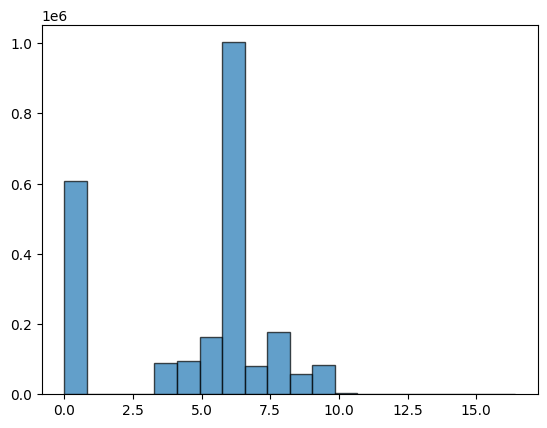

In [32]:
#RETRANSMITTED_IN_BYTES 분포 확인
plt.hist(data['RETRANSMITTED_IN_BYTES'], bins=20, edgecolor='k', alpha=0.7)

(array([6.93971e+05, 0.00000e+00, 0.00000e+00, 0.00000e+00, 1.34000e+02,
        4.69120e+04, 7.73440e+04, 2.01153e+05, 4.99627e+05, 3.72060e+04,
        2.27691e+05, 1.89287e+05, 2.29793e+05, 9.14300e+04, 5.58600e+03,
        2.84060e+04, 3.41790e+04, 2.64400e+03, 3.80000e+01, 2.30000e+01]),
 array([ 0.        ,  0.79036209,  1.58072417,  2.37108626,  3.16144834,
         3.95181043,  4.74217251,  5.5325346 ,  6.32289668,  7.11325877,
         7.90362085,  8.69398294,  9.48434502, 10.27470711, 11.06506919,
        11.85543128, 12.64579336, 13.43615545, 14.22651754, 15.01687962,
        15.80724171]),
 <BarContainer object of 20 artists>)

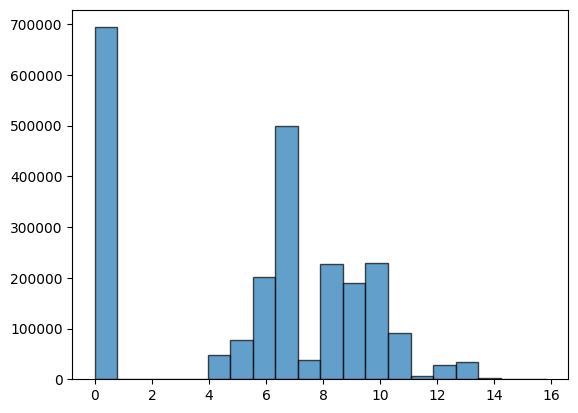

In [33]:
#RETRANSMITTED_OUT_BYTES 분포 확인
plt.hist(data['RETRANSMITTED_OUT_BYTES'], bins=20, edgecolor='k', alpha=0.7)

In [34]:
#Standardscaler 적용(RETRANSMITTED_IN_BYTES, RETRANSMITTED_OUT_BYTES)
data['RETRANSMITTED_IN_BYTES'] = scaler.fit_transform(data[['RETRANSMITTED_IN_BYTES']])
data['RETRANSMITTED_OUT_BYTES'] = scaler.fit_transform(data[['RETRANSMITTED_OUT_BYTES']])

In [35]:
data[col[20:30]].head()

,LONGEST_FLOW_PKT,SHORTEST_FLOW_PKT,MIN_IP_PKT_LEN,MAX_IP_PKT_LEN,SRC_TO_DST_SECOND_BYTES,DST_TO_SRC_SECOND_BYTES,RETRANSMITTED_IN_BYTES,RETRANSMITTED_IN_PKTS,RETRANSMITTED_OUT_BYTES,RETRANSMITTED_OUT_PKTS
0,89,73,73,89,89.000000,73.000000,-1.592040,0,-1.420695,0
1,984,52,52,984,8.883582,14.041791,0.936554,7,0.343579,6
2,1500,52,52,1500,222.852033,5.553659,0.891262,21,1.745595,196
3,89,73,73,89,178.000000,146.000000,-1.592040,0,-1.420695,0
4,81,65,65,81,162.000000,130.000000,-1.592040,0,-1.420695,0


#Feature 30~39 전처리

In [36]:
#feature 30~39번째
data[col[30:40]].head()

,SRC_TO_DST_AVG_THROUGHPUT,DST_TO_SRC_AVG_THROUGHPUT,NUM_PKTS_UP_TO_128_BYTES,NUM_PKTS_128_TO_256_BYTES,NUM_PKTS_256_TO_512_BYTES,NUM_PKTS_512_TO_1024_BYTES,NUM_PKTS_1024_TO_1514_BYTES,TCP_WIN_MAX_IN,TCP_WIN_MAX_OUT,ICMP_TYPE
0,389333,474666,4,0,0,0,0,0,0,0
1,112000,70857,34,18,2,2,0,14480,14480,50176
2,44411,1782091,288,0,4,32,352,65160,34752,50944
3,584000,712000,4,0,0,0,0,0,0,0
4,520000,648000,4,0,0,0,0,0,0,0


In [37]:
print(data['SRC_TO_DST_AVG_THROUGHPUT'].max())
print(data['DST_TO_SRC_AVG_THROUGHPUT'].max())
print(data['NUM_PKTS_UP_TO_128_BYTES'].max())
print(data['NUM_PKTS_128_TO_256_BYTES'].max())
print(data['NUM_PKTS_256_TO_512_BYTES'].max())
print(data['NUM_PKTS_512_TO_1024_BYTES'].max())
print(data['NUM_PKTS_1024_TO_1514_BYTES'].max())
print(data['TCP_WIN_MAX_IN'].max())
print(data['TCP_WIN_MAX_OUT'].max())

36000000
23530666
3840
298
2564
642
17500
65533
65531


(array([2.20000e+01, 1.55000e+02, 1.73600e+03, 1.37100e+03, 2.45500e+03,
        4.42000e+03, 1.26010e+04, 3.99270e+04, 1.09020e+05, 2.69977e+05,
        1.73139e+05, 1.59332e+05, 1.14310e+05, 1.50496e+05, 5.75020e+05,
        5.22795e+05, 1.35090e+05, 5.26760e+04, 3.90130e+04, 1.86900e+03]),
 array([ 2.48490665,  3.23061279,  3.97631894,  4.72202508,  5.46773122,
         6.21343737,  6.95914351,  7.70484966,  8.4505558 ,  9.19626194,
         9.94196809, 10.68767423, 11.43338037, 12.17908652, 12.92479266,
        13.67049881, 14.41620495, 15.16191109, 15.90761724, 16.65332338,
        17.39902952]),
 <BarContainer object of 20 artists>)

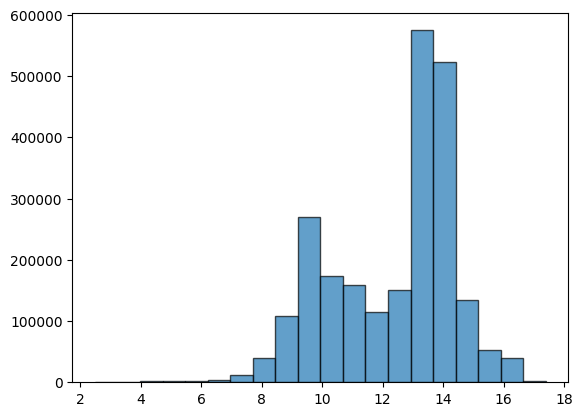

In [38]:
#feature: SRC_TO_DST_AVG_THROUGHPUT(분포 커서 log -> standardscaler)
data['SRC_TO_DST_AVG_THROUGHPUT'] = np.log1p(data['SRC_TO_DST_AVG_THROUGHPUT'])
plt.hist(data['SRC_TO_DST_AVG_THROUGHPUT'], bins=20, edgecolor='k', alpha=0.7)

In [39]:
#Standardscaler(SRC_TO_DST_AVG_THROUGHPUT)
data['SRC_TO_DST_AVG_THROUGHPUT'] = scaler.fit_transform(data[['SRC_TO_DST_AVG_THROUGHPUT']])

(array([6.61210e+04, 0.00000e+00, 1.00000e+00, 7.00000e+00, 7.80000e+01,
        6.40000e+01, 5.41000e+02, 2.04100e+03, 1.03400e+04, 5.01400e+04,
        9.03120e+04, 1.25872e+05, 1.76729e+05, 2.97360e+05, 1.05075e+05,
        4.53266e+05, 3.36673e+05, 2.12877e+05, 2.02829e+05, 2.35098e+05]),
 array([ 0.        ,  0.84869076,  1.69738151,  2.54607227,  3.39476302,
         4.24345378,  5.09214453,  5.94083529,  6.78952604,  7.6382168 ,
         8.48690755,  9.33559831, 10.18428906, 11.03297982, 11.88167057,
        12.73036133, 13.57905209, 14.42774284, 15.2764336 , 16.12512435,
        16.97381511]),
 <BarContainer object of 20 artists>)

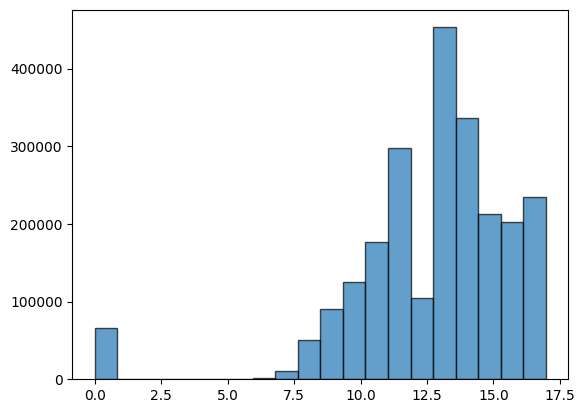

In [40]:
#feature: DST_TO_SRC_AVG_THROUGHPUT(분포 커서 log -> standardscaler)
data['DST_TO_SRC_AVG_THROUGHPUT'] = np.log1p(data['DST_TO_SRC_AVG_THROUGHPUT'])
plt.hist(data['DST_TO_SRC_AVG_THROUGHPUT'], bins=20, edgecolor='k', alpha=0.7)

In [41]:
#Standardscaler(DST_TO_SRC_AVG_THROUGHPUT)
data['DST_TO_SRC_AVG_THROUGHPUT'] = scaler.fit_transform(data[['DST_TO_SRC_AVG_THROUGHPUT']])

In [42]:
data[col[30:40]].head()

,SRC_TO_DST_AVG_THROUGHPUT,DST_TO_SRC_AVG_THROUGHPUT,NUM_PKTS_UP_TO_128_BYTES,NUM_PKTS_128_TO_256_BYTES,NUM_PKTS_256_TO_512_BYTES,NUM_PKTS_512_TO_1024_BYTES,NUM_PKTS_1024_TO_1514_BYTES,TCP_WIN_MAX_IN,TCP_WIN_MAX_OUT,ICMP_TYPE
0,0.260191,0.111840,4,0,0,0,0,0,0,0
1,-0.350091,-0.499058,34,18,2,2,0,14480,14480,50176
2,-0.803174,0.536761,288,0,4,32,352,65160,34752,50944
3,0.458796,0.242074,4,0,0,0,0,0,0,0
4,0.401941,0.211821,4,0,0,0,0,0,0,0


#Feature 40~49 전처리

In [43]:
#feature 40~49번째
data[col[40:50]].head()

,ICMP_IPV4_TYPE,DNS_QUERY_ID,DNS_QUERY_TYPE,DNS_TTL_ANSWER,FTP_COMMAND_RET_CODE,SRC_TO_DST_IAT_MIN,SRC_TO_DST_IAT_MAX,SRC_TO_DST_IAT_AVG,SRC_TO_DST_IAT_STDDEV,DST_TO_SRC_IAT_MIN
0,0,46779,1,60,0,0,0,0,0,0
1,196,0,0,0,0,0,91,12,19,0
2,199,0,0,0,0,0,1843,10,119,0
3,0,3211,1,60,0,0,0,0,0,0
4,0,5771,1,60,0,0,0,0,0,0


In [44]:
print(data['DNS_TTL_ANSWER'].max())
print(data['FTP_COMMAND_RET_CODE'].max())
print(data['SRC_TO_DST_IAT_MAX'].max())

4283358309
501
60598


In [45]:
#feature: DNS_TTL_ANSWER
data['DNS_TTL_ANSWER'].unique()

array([        60,          0,      10705,       1941,      47499,
            10706,      48208,      86400, 1771002938,          5,
           851973,      17935,      22028, 4283358309, 1925082231,
       2088875341, 4219426478,   16430662,    4435224,    7250992,
         11309747,   12725010,    3634582,    8430824,       3600,
            62897,      15437,      14669, 1634340595,      64894,
       1108682205,    4117923,      35429,   14992022, 3400622437,
       3628276791, 1208456695,      43948,       5326,      22706,
       3352446962,      25338,      36617,      54931, 2469874588,
            30929, 2518738583,      58614,      15508,  139159755,
              985,      37699, 3090595040,    3027339,   12497814,
            38894,    8994213,      63355,    3716542,    2309450,
            55483,      57216,     862342,      23660,      51765,
       2127108415,  371377316,      43853,   11237882,    6095959,
           829737,    2913442, 3024779571,      58653,      39

(array([1.998784e+06, 4.200000e+01, 3.400190e+05, 0.000000e+00,
        3.000000e+00, 1.400000e+01, 2.621000e+04, 6.900000e+01,
        1.000000e+00, 2.260000e+02, 1.800000e+01, 1.200000e+01,
        2.000000e+00, 2.000000e+00, 2.200000e+01]),
 array([ 0.        ,  1.47853355,  2.95706709,  4.43560064,  5.91413418,
         7.39266773,  8.87120128, 10.34973482, 11.82826837, 13.30680191,
        14.78533546, 16.26386901, 17.74240255, 19.2209361 , 20.69946964,
        22.17800319]),
 <BarContainer object of 15 artists>)

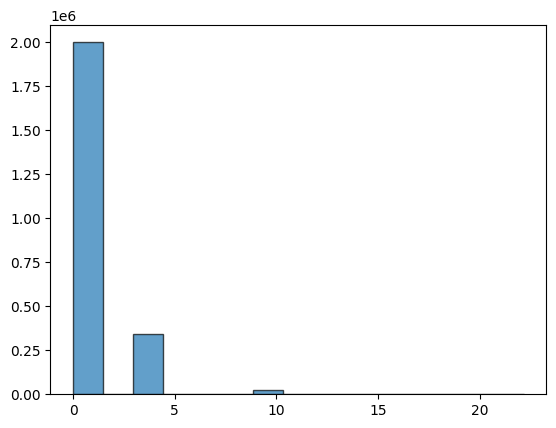

In [46]:
#feature: DNS_TTL_ANSWER(구간 커서 log -> standardscaler)
data['DNS_TTL_ANSWER'] = np.log1p(data['DNS_TTL_ANSWER'])
plt.hist(data['DNS_TTL_ANSWER'], bins=15, edgecolor='k', alpha=0.7)

In [47]:
#Standardscaler(DNS_TTL_ANSWER)
data['DNS_TTL_ANSWER']  = scaler.fit_transform(data[['DNS_TTL_ANSWER']])

In [48]:
data[col[40:50]].head()

,ICMP_IPV4_TYPE,DNS_QUERY_ID,DNS_QUERY_TYPE,DNS_TTL_ANSWER,FTP_COMMAND_RET_CODE,SRC_TO_DST_IAT_MIN,SRC_TO_DST_IAT_MAX,SRC_TO_DST_IAT_AVG,SRC_TO_DST_IAT_STDDEV,DST_TO_SRC_IAT_MIN
0,0,46779,1,1.995321,0,0,0,0,0,0
1,196,0,0,-0.406602,0,0,91,12,19,0
2,199,0,0,-0.406602,0,0,1843,10,119,0
3,0,3211,1,1.995321,0,0,0,0,0,0
4,0,5771,1,1.995321,0,0,0,0,0,0


#Feature 50~

In [49]:
#feature 50~
data[col[50:]].head()

,DST_TO_SRC_IAT_MAX,DST_TO_SRC_IAT_AVG,DST_TO_SRC_IAT_STDDEV,Label,Attack
0,0,0,0,0,Benign
1,90,12,19,0,Benign
2,1843,5,88,0,Benign
3,0,0,0,0,Benign
4,0,0,0,0,Benign


In [50]:
print(data['DST_TO_SRC_IAT_MAX'].max())

60598


In [51]:
#공격 유형별 count
data["Attack"].value_counts()

Attack
Benign            2237731
Exploits            42748
Fuzzers             33816
Generic             19651
Reconnaissance      17074
DoS                  5980
Backdoor             4659
Shellcode            2381
Analysis             1226
Worms                 158
Name: count, dtype: int64

#최종 & 전체 전처리

In [52]:
#중복된 행의 수 -> 유지
print("중복된 항목 수 :", len(data[data.duplicated()]))

중복된 항목 수 : 14815


In [53]:
#범주형 데이터
data.select_dtypes('object').head()

,IPV4_SRC_ADDR,IPV4_DST_ADDR,Attack
0,59.166.0.2,149.171.126.3,Benign
1,59.166.0.4,149.171.126.6,Benign
2,59.166.0.0,149.171.126.9,Benign
3,59.166.0.8,149.171.126.7,Benign
4,59.166.0.1,149.171.126.1,Benign


<Axes: xlabel='Attack'>

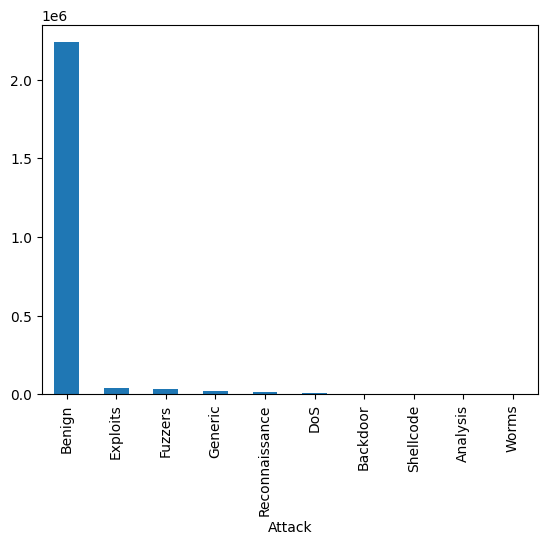

In [54]:
data["Attack"].value_counts().plot(kind='bar')

In [55]:
#feature끼리의 상관관계 분석(유사 feature 제거)
import seaborn as sns
corr=data.corr(numeric_only=True)

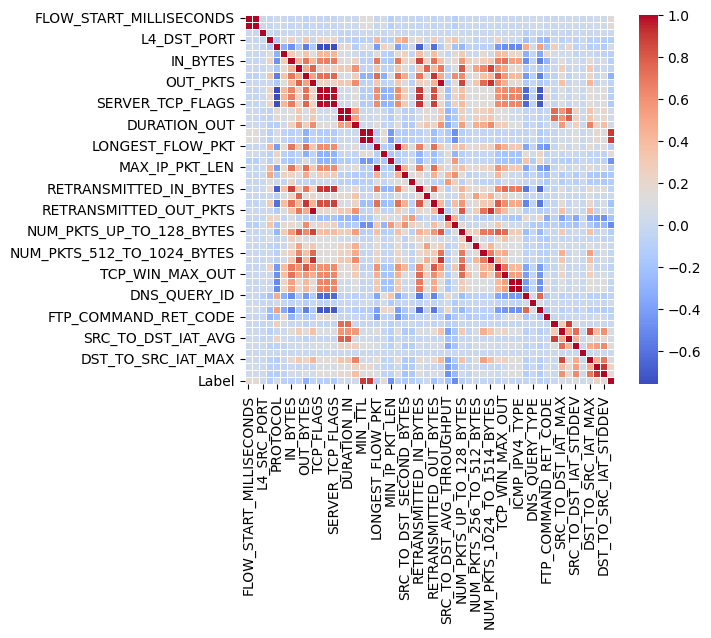

In [56]:
#feature의 상관관계 히트맵(절대값이 1에 가까울수록 두 feature의 상관도 높음)
sns.heatmap(corr, annot=False,cmap='coolwarm', linewidths=0.5, square=True)

plt.show()

In [57]:
#상관도 높은(유사한) feature 조합 찾기
from itertools import combinations
import numpy as np
from scipy.stats import pearsonr

num_feat = data.select_dtypes('number').columns.values
comb_num_feat = np.array(list(combinations(num_feat, 2)))
corr_num_feat = np.array([])
for comb in comb_num_feat:
    corr = pearsonr(data[comb[0]], data[comb[1]])[0]
    corr_num_feat = np.append(corr_num_feat, corr)

In [58]:
#유사도가 절대값 0.9 이상인 feature 쌍
high_corr_num = comb_num_feat[np.abs(corr_num_feat) >= 0.9]
high_corr_num

array([['FLOW_START_MILLISECONDS', 'FLOW_END_MILLISECONDS'],
       ['OUT_BYTES', 'RETRANSMITTED_OUT_BYTES'],
       ['OUT_PKTS', 'RETRANSMITTED_OUT_PKTS'],
       ['OUT_PKTS', 'NUM_PKTS_1024_TO_1514_BYTES'],
       ['TCP_FLAGS', 'CLIENT_TCP_FLAGS'],
       ['TCP_FLAGS', 'SERVER_TCP_FLAGS'],
       ['TCP_FLAGS', 'RETRANSMITTED_IN_BYTES'],
       ['CLIENT_TCP_FLAGS', 'SERVER_TCP_FLAGS'],
       ['CLIENT_TCP_FLAGS', 'RETRANSMITTED_IN_BYTES'],
       ['SERVER_TCP_FLAGS', 'RETRANSMITTED_IN_BYTES'],
       ['FLOW_DURATION_MILLISECONDS', 'DURATION_IN'],
       ['MIN_TTL', 'MAX_TTL'],
       ['LONGEST_FLOW_PKT', 'MAX_IP_PKT_LEN'],
       ['RETRANSMITTED_OUT_PKTS', 'NUM_PKTS_1024_TO_1514_BYTES'],
       ['ICMP_TYPE', 'ICMP_IPV4_TYPE'],
       ['DST_TO_SRC_IAT_AVG', 'DST_TO_SRC_IAT_STDDEV']], dtype='<U27')

In [59]:
data = data.drop(['L7_PROTO'], axis=1)

In [60]:
data.head()

,FLOW_START_MILLISECONDS,FLOW_END_MILLISECONDS,IPV4_SRC_ADDR,L4_SRC_PORT,IPV4_DST_ADDR,L4_DST_PORT,PROTOCOL,IN_BYTES,IN_PKTS,OUT_BYTES,OUT_PKTS,TCP_FLAGS,CLIENT_TCP_FLAGS,SERVER_TCP_FLAGS,FLOW_DURATION_MILLISECONDS,DURATION_IN,DURATION_OUT,MIN_TTL,MAX_TTL,LONGEST_FLOW_PKT,SHORTEST_FLOW_PKT,MIN_IP_PKT_LEN,MAX_IP_PKT_LEN,SRC_TO_DST_SECOND_BYTES,DST_TO_SRC_SECOND_BYTES,RETRANSMITTED_IN_BYTES,RETRANSMITTED_IN_PKTS,RETRANSMITTED_OUT_BYTES,RETRANSMITTED_OUT_PKTS,SRC_TO_DST_AVG_THROUGHPUT,DST_TO_SRC_AVG_THROUGHPUT,NUM_PKTS_UP_TO_128_BYTES,NUM_PKTS_128_TO_256_BYTES,NUM_PKTS_256_TO_512_BYTES,NUM_PKTS_512_TO_1024_BYTES,NUM_PKTS_1024_TO_1514_BYTES,TCP_WIN_MAX_IN,TCP_WIN_MAX_OUT,ICMP_TYPE,ICMP_IPV4_TYPE,DNS_QUERY_ID,DNS_QUERY_TYPE,DNS_TTL_ANSWER,FTP_COMMAND_RET_CODE,SRC_TO_DST_IAT_MIN,SRC_TO_DST_IAT_MAX,SRC_TO_DST_IAT_AVG,SRC_TO_DST_IAT_STDDEV,DST_TO_SRC_IAT_MIN,DST_TO_SRC_IAT_MAX,DST_TO_SRC_IAT_AVG,DST_TO_SRC_IAT_STDDEV,Label,Attack
0,1424242193040,1424242193043,59.166.0.2,4894,149.171.126.3,53,17,-1.322581,2,-1.023279,2,0,0,0,2,0,0,31,31,89,73,73,89,89.000000,73.000000,-1.592040,0,-1.420695,0,0.260191,0.111840,4,0,0,0,0,0,0,0,0,46779,1,1.995321,0,0,0,0,0,0,0,0,0,0,Benign
1,1424242192744,1424242193079,59.166.0.4,52671,149.171.126.6,31992,6,0.845318,28,0.111115,28,27,27,27,335,334,334,31,32,984,52,52,984,8.883582,14.041791,0.936554,7,0.343579,6,-0.350091,-0.499058,34,18,2,2,0,14480,14480,50176,196,0,0,-0.406602,0,0,91,12,19,0,90,12,19,0,Benign
2,1424242190649,1424242193109,59.166.0.0,47290,149.171.126.9,6881,6,1.512126,238,2.215747,438,27,27,27,2460,2459,2459,31,32,1500,52,52,1500,222.852033,5.553659,0.891262,21,1.745595,196,-0.803174,0.536761,288,0,4,32,352,65160,34752,50944,199,0,0,-0.406602,0,0,1843,10,119,0,1843,5,88,0,Benign
3,1424242193145,1424242193146,59.166.0.8,43310,149.171.126.7,53,17,-1.322581,2,-1.023279,2,0,0,0,1,0,0,31,31,89,73,73,89,178.000000,146.000000,-1.592040,0,-1.420695,0,0.458796,0.242074,4,0,0,0,0,0,0,0,0,3211,1,1.995321,0,0,0,0,0,0,0,0,0,0,Benign
4,1424242193239,1424242193241,59.166.0.1,45870,149.171.126.1,53,17,-1.394659,2,-1.061062,2,0,0,0,1,0,0,31,31,81,65,65,81,162.000000,130.000000,-1.592040,0,-1.420695,0,0.401941,0.211821,4,0,0,0,0,0,0,0,0,5771,1,1.995321,0,0,0,0,0,0,0,0,0,0,Benign


In [61]:
# 각자 방법에 맞게 [FLOW_START_MILLISECONDS, FLOW_END_MILLISECONDS, Attack] drop 해서 사용.

In [62]:
# 최종 Feature 
[ 
    "IPV4_SRC_ADDR", "IPV4_DST_ADDR", 
    "L4_SRC_PORT", "L4_DST_PORT", 
    "PROTOCOL","IN_BYTES","IN_PKTS","OUT_BYTES","OUT_PKTS","TCP_FLAGS","CLIENT_TCP_FLAGS","SERVER_TCP_FLAGS",
    "FLOW_DURATION_MILLISECONDS","DURATION_IN","DURATION_OUT","MIN_TTL","MAX_TTL","LONGEST_FLOW_PKT","SHORTEST_FLOW_PKT",
    "MIN_IP_PKT_LEN","MAX_IP_PKT_LEN","SRC_TO_DST_SECOND_BYTES","DST_TO_SRC_SECOND_BYTES","RETRANSMITTED_IN_BYTES",
    "RETRANSMITTED_IN_PKTS","RETRANSMITTED_OUT_BYTES","RETRANSMITTED_OUT_PKTS","SRC_TO_DST_AVG_THROUGHPUT",
    "DST_TO_SRC_AVG_THROUGHPUT","NUM_PKTS_UP_TO_128_BYTES","NUM_PKTS_128_TO_256_BYTES","NUM_PKTS_256_TO_512_BYTES",
    "NUM_PKTS_512_TO_1024_BYTES","NUM_PKTS_1024_TO_1514_BYTES","TCP_WIN_MAX_IN","TCP_WIN_MAX_OUT","ICMP_TYPE",
    "ICMP_IPV4_TYPE","DNS_QUERY_ID","DNS_QUERY_TYPE","DNS_TTL_ANSWER","FTP_COMMAND_RET_CODE","SRC_TO_DST_IAT_MIN",
    "SRC_TO_DST_IAT_MAX","SRC_TO_DST_IAT_AVG","SRC_TO_DST_IAT_STDDEV","DST_TO_SRC_IAT_MIN","DST_TO_SRC_IAT_MAX",
    "DST_TO_SRC_IAT_AVG","DST_TO_SRC_IAT_STDDEV","Label"
]

['IPV4_SRC_ADDR',
 'IPV4_DST_ADDR',
 'L4_SRC_PORT',
 'L4_DST_PORT',
 'PROTOCOL',
 'IN_BYTES',
 'IN_PKTS',
 'OUT_BYTES',
 'OUT_PKTS',
 'TCP_FLAGS',
 'CLIENT_TCP_FLAGS',
 'SERVER_TCP_FLAGS',
 'FLOW_DURATION_MILLISECONDS',
 'DURATION_IN',
 'DURATION_OUT',
 'MIN_TTL',
 'MAX_TTL',
 'LONGEST_FLOW_PKT',
 'SHORTEST_FLOW_PKT',
 'MIN_IP_PKT_LEN',
 'MAX_IP_PKT_LEN',
 'SRC_TO_DST_SECOND_BYTES',
 'DST_TO_SRC_SECOND_BYTES',
 'RETRANSMITTED_IN_BYTES',
 'RETRANSMITTED_IN_PKTS',
 'RETRANSMITTED_OUT_BYTES',
 'RETRANSMITTED_OUT_PKTS',
 'SRC_TO_DST_AVG_THROUGHPUT',
 'DST_TO_SRC_AVG_THROUGHPUT',
 'NUM_PKTS_UP_TO_128_BYTES',
 'NUM_PKTS_128_TO_256_BYTES',
 'NUM_PKTS_256_TO_512_BYTES',
 'NUM_PKTS_512_TO_1024_BYTES',
 'NUM_PKTS_1024_TO_1514_BYTES',
 'TCP_WIN_MAX_IN',
 'TCP_WIN_MAX_OUT',
 'ICMP_TYPE',
 'ICMP_IPV4_TYPE',
 'DNS_QUERY_ID',
 'DNS_QUERY_TYPE',
 'DNS_TTL_ANSWER',
 'FTP_COMMAND_RET_CODE',
 'SRC_TO_DST_IAT_MIN',
 'SRC_TO_DST_IAT_MAX',
 'SRC_TO_DST_IAT_AVG',
 'SRC_TO_DST_IAT_STDDEV',
 'DST_TO_SRC_IAT_MI

In [63]:
data.to_csv("/Users/yub/Documents/ssu_32/CapstoneDesign1/Datasets/NF_v3_pre.csv", index=False)